In [1]:
include("functions.jl")
using Plots, JLD2, LaTeXStrings, FileIO

In [83]:
function single_particle_evolution_fidelity(α, γ_Decay, t)
    β = sqrt(1-α^2)
    fidelity = (α^4 * exp(-γ_Decay*t)) + β^4 + (2 * α^2 * β^2)
    return sqrt(fidelity)
end

single_particle_evolution_fidelity (generic function with 1 method)

## Gamma = 1e-5

In [112]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/codework/bitflip_code/results_data/storage_files/N_atoms=5_γ_decay=1.0e-5_s10_Ntraj=10000_avg.jld2"
e10 = avg_population_data[:abc][10*Int(T1)]
s10 = avg_population_data[:abc][end]
c10 = avg_fidelity_data[end];

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/codework/bitflip_code/results_data/storage_files/N_atoms=5_γ_decay=1.0e-5_s11_Ntraj=10000_avg.jld2"
e11 = avg_population_data[:abc][10*Int(T1)]
s11 = avg_population_data[:abc][end]
c11 = avg_fidelity_data[end];

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/codework/bitflip_code/results_data/storage_files/N_atoms=5_γ_decay=1.0e-5_s12_Ntraj=10000_avg.jld2"
e12 = avg_population_data[:abc][10*Int(T1)]
s12 = avg_population_data[:abc][end]
c12 = avg_fidelity_data[end];

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/codework/bitflip_code/results_data/storage_files/N_atoms=5_γ_decay=1.0e-5_s13_Ntraj=10000_avg.jld2"
e13 = avg_population_data[:abc][10*Int(T1)]
s13 = avg_population_data[:abc][end]
c13 = avg_fidelity_data[end];

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/codework/bitflip_code/results_data/storage_files/N_atoms=5_γ_decay=1.0e-5_s14_Ntraj=10000_avg.jld2"
e14 = avg_population_data[:abc][10*Int(T1)]
s14 = avg_population_data[:abc][end]
c14 = avg_fidelity_data[end];

e_s = [e10,e11,e12,e13,e14]
s_s = [s10,s11,s12,s13,s14]
c_s = [c10,c11,c12,c13,c14];

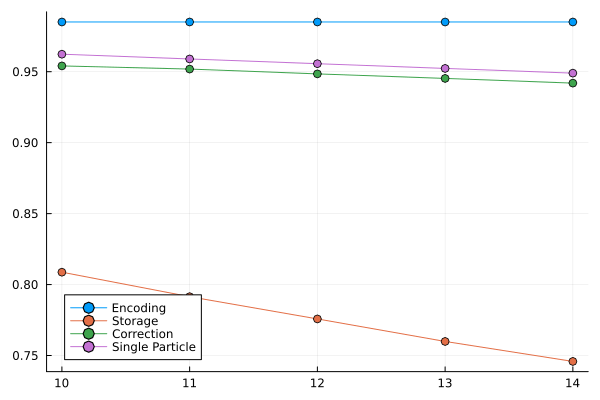

In [114]:
idx = [10,11,12,13,14]
single_particle = zeros(Float64, length(idx))
for i in 1:length(idx)
    single_particle[i] = single_particle_evolution_fidelity(1,1.0e-5,(idx[i]+1)*698)
end

plot(idx, e_s, label="Encoding", marker=:o)
plot!(idx, s_s, label="Storage", marker=:o)
plot!(idx, c_s, label="Correction", marker=:o)
plot!(idx, single_particle, label="Single Particle", marker=:o)

### S10

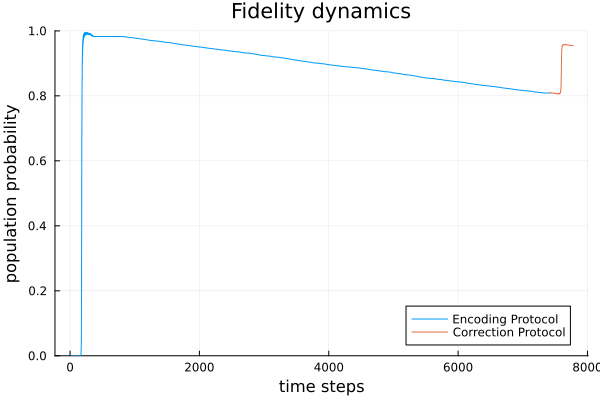

In [ ]:
# @load "Z:/master_work/5_atom_correction/decay_1e_4/N_atoms=5_γ_decay=0.0001_Ntraj=100_avg.jld2"
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/codework/bitflip_code/results_data/storage_files/N_atoms=5_γ_decay=1.0e-5_s10_Ntraj=10000_avg.jld2"

avg_population_data = avg_population_data;
avg_corrected_population_data = avg_corrected_population_data;
avg_fidelity_data = avg_fidelity_data;


t1 = [0.0: 0.1: Int(T1+10*698+T2);]
t2 = [Int(T1+10*698+T2):0.1:(Int(T1+10*698+T2)+360);]

avg_population_data1 = avg_population_data[:abc][1:length(t1)]

plot(t1, avg_population_data1,  ylim=[0,1], label="Encoding Protocol", xlabel="time steps", ylabel="population probability", title="Fidelity dynamics")
plot!(t2,avg_fidelity_data, ylim=[0,1], label="Correction Protocol")

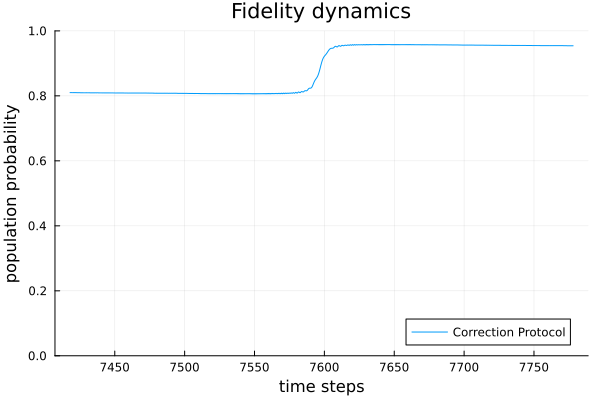

In [59]:
plot(t2, avg_fidelity_data, ylim=[0,1], label="Correction Protocol", xlabel="time steps", ylabel="population probability", title="Fidelity dynamics")

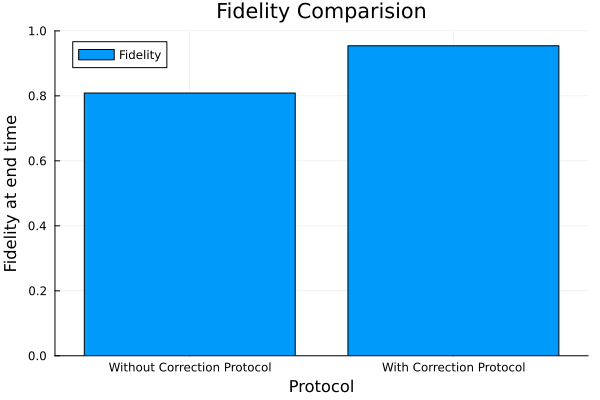

In [60]:
x = ["Without Correction Protocol", "With Correction Protocol"]
y = [avg_population_data1[end], avg_fidelity_data[end]]
bar(x,y, ylim=[0,1], label="Fidelity", title="Fidelity Comparision", xlabel="Protocol", ylabel="Fidelity at end time")

In [61]:
println("Fidelity at end time without correction protocol: ", avg_population_data1[end])
println("Fidelity at end time with correction protocol: ", avg_fidelity_data[end])

Fidelity at end time without correction protocol: 0.8087155036568642
Fidelity at end time with correction protocol: 0.9540817893365108
